# Verification: beta-catenin destruction complex (Barua and Hlavacek, 2013)

This notebook verifies the two curated BNGL files in this folder against the
paper Barua D, Hlavacek WS (2013), *Modeling the effect of APC truncation on
destruction complex function in colorectal cancer cells*, PLoS Comput Biol
9(9):e1003217, at two independent levels.

**Model-specification verification.** For each model, BioNetGen expands the
rules into a mass-action reaction network and integrates it with CVODE. We
re-parse the generated `.net` file and integrate the *same* network with an
independently written SciPy right-hand side (built from the stoichiometry and
mass-action rate laws), then check that the two ODE solutions agree. This
verifies BioNetGen's numerical solution of the generated network; network
generation itself is a BioNetGen core function and is trusted.

**Reported-data verification.** Both published dose-response curves are
reproduced and compared quantitatively to data digitized from the paper:

* base model (normal cell, full-length APC) vs **Fig. 5A**;
* APC1338 variant (SW480 cell, truncated APC) vs **Fig. 6A**.

Both figures plot relative beta-catenin level (normalized to the nominal
normal-cell level, 35 nM) against the relative amount of transfected APC.

Units: the model is population-based (molecule counts). Following Table 1 of
Barua and Hlavacek (2013), 1 nM = 315.4 molecules/cell.

Plot convention: **solid lines = BioNetGen**, **open markers = independent
SciPy ODE**; digitized paper data are shown as thick gray curves.


## 0. Imports and paths

In [1]:
import os
import re
import shutil
import subprocess
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.sparse import csc_matrix

BASE_STEM = "beta_catenin_destruction_complex_barua2013"
VAR_STEM = "beta_catenin_destruction_complex_barua2013_apc1338"

# molecules per nM per cell (AXINtot = 3154 molecules = 10 nM; Table 1)
CONV = 315.4

def find_model_dir():
    for candidate in (Path.cwd(), Path.cwd() / "models" / BASE_STEM,
                      Path.cwd().parent / "models" / BASE_STEM):
        if (candidate / f"{BASE_STEM}.bngl").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the model directory")

MODEL_DIR = find_model_dir()
os.chdir(MODEL_DIR)
REF_DIR = MODEL_DIR / "reference"
PNG_FILE = MODEL_DIR / "verify_barua2013.png"
print(f"Model directory: {MODEL_DIR}")


Model directory: /Users/l119605/Code/BNGL-Models/models/beta_catenin_destruction_complex_barua2013


## 1. Run BioNetGen: generate network and relax to steady state

Each committed `.bngl` file ends with a `parameter_scan` protocol that
integrates one ODE per APC level and takes a few minutes. For this notebook we
only need the generated network and the single relaxation run, so we strip the
scan protocol before running BioNetGen. The full scan is reproduced separately
below with the independent SciPy integrator and cross-checked against the
committed BioNetGen scan output.


In [2]:
def bionetgen_command(model_name):
    env_bng2 = os.environ.get("BNG2_PL")
    if env_bng2 and Path(env_bng2).expanduser().is_file():
        return ["perl", str(Path(env_bng2).expanduser()), model_name]
    local_bng2 = Path.home() / "Simulations" / "BioNetGen-2.9.3" / "BNG2.pl"
    if local_bng2.is_file():
        return ["perl", str(local_bng2), model_name]
    cli = shutil.which("bionetgen")
    if cli:
        return [cli, "run", "-i", model_name]
    raise FileNotFoundError("BioNetGen not found. Set BNG2_PL or install bionetgen.")

def strip_scan(bngl_text):
    # Keep everything up to the scan protocol header; close the actions block.
    marker = "  # Concentration-dependent effect"
    idx = bngl_text.index(marker)
    return bngl_text[:idx] + "end actions\n"

def run_relaxation(stem):
    bngl = (MODEL_DIR / f"{stem}.bngl").read_text()
    tmp = tempfile.mkdtemp(prefix="barua_bng_")
    run_bngl = Path(tmp) / f"{stem}.bngl"
    run_bngl.write_text(strip_scan(bngl))
    cmd = bionetgen_command(run_bngl.name)
    res = subprocess.run(cmd, cwd=tmp, capture_output=True, text=True, timeout=300)
    assert res.returncode == 0, res.stderr or res.stdout[-2000:]
    net = Path(tmp) / f"{stem}.net"
    gdat = Path(tmp) / f"{stem}_ode.gdat"
    assert net.exists() and gdat.exists()
    return net, load_gdat(gdat)

def load_gdat(path):
    with open(path) as fh:
        header = fh.readline().lstrip("#").split()
    data = np.loadtxt(path)
    return header, np.atleast_2d(data)

runs = {}
for stem in (BASE_STEM, VAR_STEM):
    net, (hdr, data) = run_relaxation(stem)
    runs[stem] = {"net": net, "header": hdr, "data": data}
    bcat_ss = data[-1, hdr.index("Obs_Tot_bCat")]
    print(f"{stem}: relaxation done, steady-state Obs_Tot_bCat = "
          f"{bcat_ss:.1f} molecules = {bcat_ss / CONV:.2f} nM")


beta_catenin_destruction_complex_barua2013: relaxation done, steady-state Obs_Tot_bCat = 11320.5 molecules = 35.89 nM


beta_catenin_destruction_complex_barua2013_apc1338: relaxation done, steady-state Obs_Tot_bCat = 41498.3 molecules = 131.57 nM


## 2. Confirm fresh BioNetGen output matches the committed reference

The `reference/` folder holds the committed relaxation output for each model.
A fresh run must reproduce it, and the steady-state levels must match the
paper: 35 nM (normal cell) and about 132 nM = 3.7x (SW480 cell).

In [3]:
def compare_to_reference(stem, hdr, data):
    ref_hdr, ref = load_gdat(REF_DIR / f"{stem}_ode.gdat")
    assert ref_hdr == hdr, (ref_hdr, hdr)
    # compare final-row observables
    diff = np.abs(data[-1, 1:] - ref[-1, 1:])
    scale = np.maximum(np.abs(ref[-1, 1:]), 1.0)
    return float((diff / scale).max())

base_ss = runs[BASE_STEM]["data"][-1, runs[BASE_STEM]["header"].index("Obs_Tot_bCat")]
var_ss = runs[VAR_STEM]["data"][-1, runs[VAR_STEM]["header"].index("Obs_Tot_bCat")]
NOMINAL = base_ss  # normal-cell nominal beta-catenin (molecules)

for stem in (BASE_STEM, VAR_STEM):
    err = compare_to_reference(stem, runs[stem]["header"], runs[stem]["data"])
    print(f"{stem}: fresh vs committed reference, max scaled error = {err:.2e}")

print()
print(f"Normal-cell nominal beta-catenin : {base_ss:8.1f} molecules = "
      f"{base_ss / CONV:6.2f} nM  (paper: 35 nM)")
print(f"SW480 (APC1338) beta-catenin     : {var_ss:8.1f} molecules = "
      f"{var_ss / CONV:6.2f} nM  = {var_ss / base_ss:.2f}x nominal  (paper: ~3.7x)")


beta_catenin_destruction_complex_barua2013: fresh vs committed reference, max scaled error = 0.00e+00
beta_catenin_destruction_complex_barua2013_apc1338: fresh vs committed reference, max scaled error = 0.00e+00

Normal-cell nominal beta-catenin :  11320.5 molecules =  35.89 nM  (paper: 35 nM)
SW480 (APC1338) beta-catenin     :  41498.3 molecules = 131.57 nM  = 3.67x nominal  (paper: ~3.7x)


## 3. Independent ODE from the generated `.net` (model-specification verification)

We parse each generated network and assemble the mass-action ODE system
independently: `dy/dt = S . r`, where `S` is the stoichiometry matrix and each
reaction rate `r_j` is a rate constant times its reactant populations (all
rules here are zero-, first-, or second-order). Integrating this with SciPy and
comparing the observables to BioNetGen's CVODE output tests the numerical
solution of the generated network.

In [4]:
def parse_net(path):
    params, y0, patterns, reactions, groups = {}, [], [], [], []
    block = None
    for raw in open(path):
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        if line.startswith("begin "):
            block = line.split()[1]; continue
        if line.startswith("end "):
            block = None; continue
        body = line.split("#", 1)[0].strip()
        if not body:
            continue
        p = body.split()
        if block == "parameters":
            params[p[1]] = float(eval("".join(p[2:]), {"__builtins__": {}}, params))
        elif block == "species":
            patterns.append(p[1])
            y0.append(float(eval("".join(p[2:]), {"__builtins__": {}}, params)))
        elif block == "reactions":
            r = [int(x) - 1 for x in p[1].split(",") if x != "0"]
            pr = [int(x) - 1 for x in p[2].split(",") if x != "0"]
            k = float(eval("".join(p[3:]), {"__builtins__": {}}, params))
            reactions.append((r, pr, k))
        elif block == "groups":
            g = body.split(None, 2)
            members = [] if len(g) < 3 else [
                (int(t.split("*")[-1]) - 1, float(t.split("*")[0]) if "*" in t else 1.0)
                for t in g[2].split(",") if t]
            groups.append((g[1], members))
    n, m = len(y0), len(reactions)
    rows, cols, vals = [], [], []
    kk = np.empty(m); ra = np.full(m, -1); rb = np.full(m, -1)
    for j, (r, pr, k) in enumerate(reactions):
        kk[j] = k
        if len(r) > 2:
            raise ValueError("only <=2nd order supported")
        if r:
            ra[j] = r[0]
        if len(r) > 1:
            rb[j] = r[1]
        for s in r:
            rows.append(s); cols.append(j); vals.append(-1.0)
        for s in pr:
            rows.append(s); cols.append(j); vals.append(1.0)
    S = csc_matrix((vals, (rows, cols)), shape=(n, m))
    gr, gc, gv, gnames = [], [], [], []
    for i, (name, members) in enumerate(groups):
        gnames.append(name)
        for sp, w in members:
            gr.append(i); gc.append(sp); gv.append(w)
    G = csc_matrix((gv, (gr, gc)), shape=(len(groups), n))
    return dict(params=params, y0=np.array(y0), patterns=patterns, S=S,
                k=kk, ra=ra, rb=rb, G=G, gnames=gnames)

def make_rhs(net):
    k, ra, rb, S = net["k"], net["ra"], net["rb"], net["S"]
    fo = np.flatnonzero((ra >= 0) & (rb < 0))
    so = np.flatnonzero(rb >= 0)
    def rhs(_t, y):
        r = k.copy()
        r[fo] *= y[ra[fo]]
        r[so] *= y[ra[so]] * y[rb[so]]
        return S @ r
    return rhs

def integrate(net, y0, t_eval):
    sol = solve_ivp(make_rhs(net), (float(t_eval[0]), float(t_eval[-1])), y0,
                    method="LSODA", t_eval=t_eval, rtol=1e-8, atol=1e-4)
    assert sol.success, sol.message
    return sol

for stem in (BASE_STEM, VAR_STEM):
    net = parse_net(runs[stem]["net"])
    runs[stem]["net_parsed"] = net
    hdr, data = runs[stem]["header"], runs[stem]["data"]
    assert net["gnames"] == hdr[1:], (net["gnames"], hdr[1:])
    sol = integrate(net, net["y0"], data[:, 0])
    obs = (net["G"] @ sol.y).T
    diff = np.abs(obs - data[:, 1:])
    scale = np.maximum(np.abs(data[:, 1:]), 1.0)
    runs[stem]["scipy_obs"] = obs
    print(f"{stem}: {net['y0'].size} species, {net['k'].size} reactions; "
          f"SciPy vs BNG max scaled error over trajectory = {(diff / scale).max():.2e}")


beta_catenin_destruction_complex_barua2013: 409 species, 2737 reactions; SciPy vs BNG max scaled error over trajectory = 9.21e-05
beta_catenin_destruction_complex_barua2013_apc1338: 145 species, 715 reactions; SciPy vs BNG max scaled error over trajectory = 7.47e-05


## 4. Reproduce Fig. 5A and Fig. 6A (reported-data verification)

Both figures are steady-state dose-response curves. Because the reaction
network topology does not depend on the total APC amount (only the free-APC
initial population does), we scan by setting the free-APC species population to
`endogenous * (1 + x)` for relative transfected level `x` and integrating each
point to steady state with the independent SciPy system. Steady-state
beta-catenin is normalized by the normal-cell nominal level (base model), as in
the paper. We compare to the digitized curves and cross-check the committed
BioNetGen `parameter_scan` output at its own APC values.

**Tolerance.** The reported data are thick plotted curves (line width ~2-3 px on
the 300-dpi render), so we accept point-wise agreement within 6% relative error,
which bounds line-thickness and axis-calibration uncertainty in the
digitization. The sub-1% medians show the curves effectively coincide.

In [5]:
def free_apc_index(net, apc_prefix):
    # the free-APC monomer is the nonzero seed species whose pattern is APC/APC1338 only
    for i, (pat, y) in enumerate(zip(net["patterns"], net["y0"])):
        if y > 0 and pat.startswith(apc_prefix + "(") and "." not in pat:
            return i
    raise LookupError(apc_prefix)

def dose_response(net, apc_prefix, endog, x_rel, t_end=250000.0):
    idx = free_apc_index(net, apc_prefix)
    gi = net["gnames"].index("Obs_Tot_bCat")
    out = np.empty(len(x_rel))
    for j, x in enumerate(x_rel):
        y0 = net["y0"].copy()
        y0[idx] = endog * (1.0 + x)
        sol = solve_ivp(make_rhs(net), (0.0, t_end), y0, method="LSODA",
                        t_eval=[t_end], rtol=1e-8, atol=1e-4)
        assert sol.success, sol.message
        out[j] = (net["G"] @ sol.y[:, -1])[gi]
    return out

x_rel = np.logspace(-2, 2, 15)
base_net = runs[BASE_STEM]["net_parsed"]
var_net = runs[VAR_STEM]["net_parsed"]
ENDOG = 31540.0  # endogenous APC / APC1338 (100 nM)

model_fig5A = dose_response(base_net, "APC", ENDOG, x_rel) / NOMINAL
model_fig6A = dose_response(var_net, "APC1338", ENDOG, x_rel) / NOMINAL

# digitized reported data
dig5 = np.loadtxt(REF_DIR / "barua2013_fig5A_fulllength_apc_digitized.csv", delimiter=",")
dig6 = np.loadtxt(REF_DIR / "barua2013_fig6A_apc1338_digitized.csv", delimiter=",")

def dig_interp(dig, x):
    return np.interp(np.log10(x), np.log10(dig[:, 0]), dig[:, 1])

# Digitization tolerance: the paper curves are thick plotted lines (roughly
# 2-3 px wide on the 300-dpi render), read off with axis calibration, so
# point-wise deviations up to ~6% are within line-thickness / digitization
# uncertainty. The sub-1% medians confirm the curves coincide.
TOL_DIGITIZED = 0.06
for label, model, dig in [("Fig. 5A", model_fig5A, dig5), ("Fig. 6A", model_fig6A, dig6)]:
    ref = dig_interp(dig, x_rel)
    rel = np.abs(model - ref) / ref
    print(f"{label}: model vs digitized  max rel err = {rel.max():.3f}, "
          f"median = {np.median(rel):.3f}  (tolerance {TOL_DIGITIZED:.2f})")
    assert rel.max() < TOL_DIGITIZED, f"{label} exceeds digitization tolerance"

# cross-check committed BNG parameter_scan output against the SciPy model
def load_scan(path):
    hdr = open(path).readline().lstrip("#").split()
    return hdr, np.atleast_2d(np.loadtxt(path))

for stem, apc_prefix, net in [(BASE_STEM, "APC", base_net), (VAR_STEM, "APC1338", var_net)]:
    hdr, scan = load_scan(REF_DIR / f"{stem}_scan.scan")
    par = scan[:, 0]
    bng_rel = scan[:, hdr.index("Obs_Tot_bCat")] / NOMINAL
    xr = par / ENDOG - 1.0
    idx = free_apc_index(net, apc_prefix)
    gi = net["gnames"].index("Obs_Tot_bCat")
    sci_rel = np.empty(len(par))
    for j, p in enumerate(par):
        y0 = net["y0"].copy(); y0[idx] = p
        sol = solve_ivp(make_rhs(net), (0.0, 250000.0), y0, method="LSODA",
                        t_eval=[250000.0], rtol=1e-8, atol=1e-4)
        sci_rel[j] = (net["G"] @ sol.y[:, -1])[gi] / NOMINAL
    rel = np.abs(bng_rel - sci_rel) / np.maximum(sci_rel, 1e-9)
    print(f"{stem}: BNG parameter_scan vs SciPy  max rel err = {rel.max():.2e} "
          f"over {len(par)} points")


Fig. 5A: model vs digitized  max rel err = 0.018, median = 0.007  (tolerance 0.06)
Fig. 6A: model vs digitized  max rel err = 0.033, median = 0.004  (tolerance 0.06)


beta_catenin_destruction_complex_barua2013: BNG parameter_scan vs SciPy  max rel err = 8.17e-04 over 11 points


beta_catenin_destruction_complex_barua2013_apc1338: BNG parameter_scan vs SciPy  max rel err = 1.19e-04 over 11 points


## 5. Overlay figure

Top row: reported-data verification. Digitized Fig. 5A / 6A (thick gray) with
the curated-model SciPy dose-response (solid line) and the committed BioNetGen
`parameter_scan` points (open markers).

Bottom row: model-specification verification. Relaxation of beta-catenin and
its phospho-forms; BioNetGen (solid lines) vs independent SciPy ODE (open
markers, subsampled).

Saved verify_barua2013.png


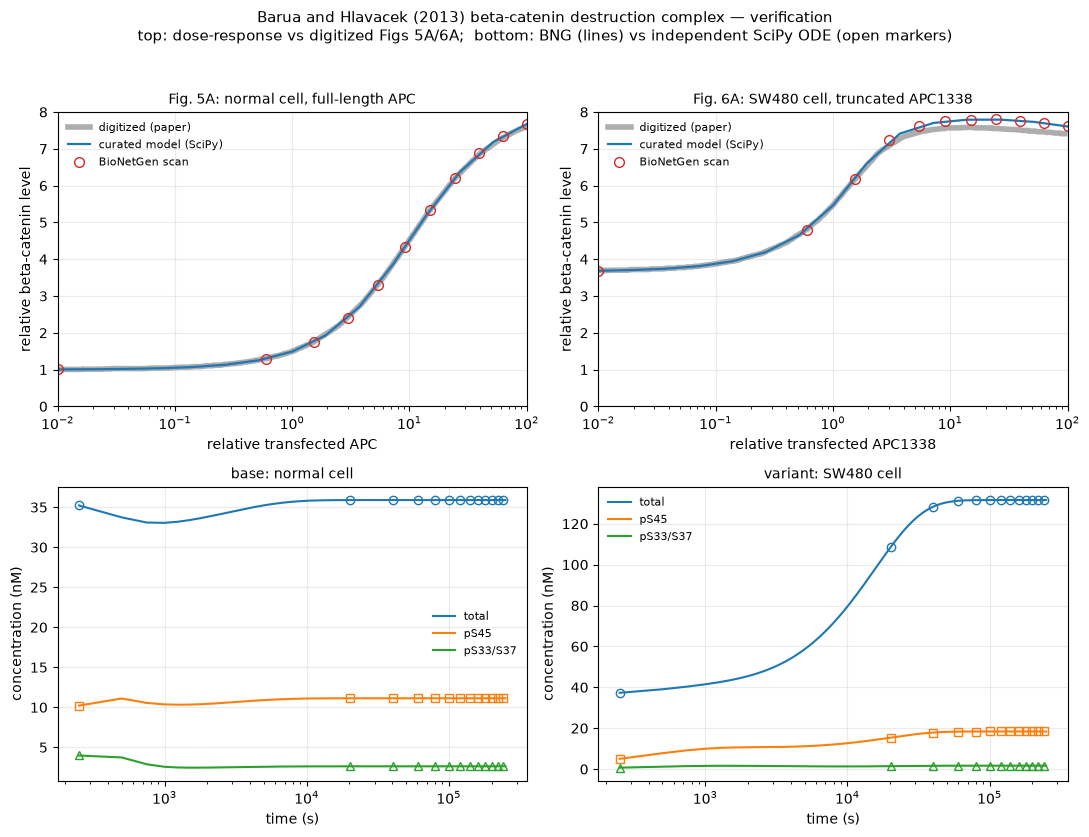

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# --- Top row: dose-response reproductions ---
def scan_points(stem, apc_prefix, net):
    hdr, scan = load_scan(REF_DIR / f"{stem}_scan.scan")
    return scan[:, 0] / ENDOG - 1.0, scan[:, hdr.index("Obs_Tot_bCat")] / NOMINAL

top = [
    (axes[0, 0], "Fig. 5A: normal cell, full-length APC", dig5, model_fig5A,
     scan_points(BASE_STEM, "APC", base_net), "relative transfected APC"),
    (axes[0, 1], "Fig. 6A: SW480 cell, truncated APC1338", dig6, model_fig6A,
     scan_points(VAR_STEM, "APC1338", var_net), "relative transfected APC1338"),
]
for ax, title, dig, model, (bx, by), xlab in top:
    ax.plot(dig[:, 0], dig[:, 1], color="0.6", lw=4, alpha=0.8, label="digitized (paper)")
    ax.plot(x_rel, model, color=colors[0], lw=1.6, label="curated model (SciPy)")
    ax.plot(bx, by, "o", mfc="none", mec=colors[3], ms=7, label="BioNetGen scan")
    ax.set_xscale("log"); ax.set_xlim(1e-2, 1e2); ax.set_ylim(0, 8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlab); ax.set_ylabel("relative beta-catenin level")
    ax.grid(alpha=0.25); ax.legend(frameon=False, fontsize=8, loc="upper left")

# --- Bottom row: relaxation overlays (BNG lines vs SciPy markers) ---
obs_plot = [("Obs_Tot_bCat", "total"), ("Obs_bCat_pS45", "pS45"),
            ("Obs_bCat_pS33S37", "pS33/S37")]
markers = ["o", "s", "^"]
bottom = [(axes[1, 0], BASE_STEM, "base: normal cell"),
          (axes[1, 1], VAR_STEM, "variant: SW480 cell")]
for ax, stem, title in bottom:
    hdr, data = runs[stem]["header"], runs[stem]["data"]
    sci = runs[stem]["scipy_obs"]
    t = data[:, 0]
    sub = t > 0
    ss = np.where(sub)[0][::80]
    for c, (name, lab) in enumerate(obs_plot):
        col = hdr.index(name)
        ax.plot(t[sub], data[sub, col] / CONV, color=colors[c], lw=1.5, label=lab)
        ax.plot(t[ss], sci[ss, col - 1] / CONV, linestyle="none", marker=markers[c],
                mfc="none", mec=colors[c], ms=6)
    ax.set_xscale("log"); ax.set_xlabel("time (s)")
    ax.set_ylabel("concentration (nM)"); ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.25); ax.legend(frameon=False, fontsize=8)

fig.suptitle("Barua and Hlavacek (2013) beta-catenin destruction complex — verification\n"
             "top: dose-response vs digitized Figs 5A/6A;  bottom: BNG (lines) vs "
             "independent SciPy ODE (open markers)", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(PNG_FILE, dpi=150)
print(f"Saved {PNG_FILE.name}")
